<font size=5  color=#12d0ff> **[LELEC2900] - Signal Processing <br><br> 
Python05 - Kalman filtering** </font> <br><br><br>

<font size=4>
Prof. L. Vandendorpe<br>
Prof. G. Bianchin (replacing Prof. L. Jacques)<br>
Dr. G. Monnoyer (replacing Prof. L. Jacques)
<br><br>
Anne-Sophie Collin (anne-sophie.collin@uclouvain.be)<br> 
Edouard Couplet (edouard.couplet@uclouvain.be)<br>
Florian Quatresooz (florian.quatresooz@uclouvain.be) <br>
Mathieu Reniers (mathieu.reniers@uclouvain.be)<br>
Audrey Vermeulen (audrey.vermeulen@uclouvain.be)<br>
<br>
</font>

<font size=5 color=#12a0ff> **1. Preliminary remarks** </font> <br> 

<font size=3 color=#12a0ff> **1.1. About the wording 'filter'** </font> <br> 

In the previous session, FIR and IIR filters have been studied. In this framework, the word *filter* has to be understood as a linear time invariant system which modifies the spectrum of an input signal (e.g. lowpass or highpass filter,...).

In this session, the Kalman filter will be implemented. As explained below, the Kalman filter enables to estimate some variables based on noisy observations. In this context, the word *filter* should be understood as estimation algorithm.

<font size=3 color=#12a0ff> **1.2 Course material** </font> <br> 

The reference for the Kalman filter are the slides covered by Prof. L. Jacques + this Python session.

<font size=5 color=#12a0ff> **2. Kalman equations** </font> <br> 

Let us first recall the general equations of the Kalman filter and predictor.

<font size=3 color=#12a0ff> **2.1 State model** </font> <br> 


Let us assume that a signal $x$ and its observations $y$ can be represented by the following state-space representation:
	

\begin{equation*}
		\left\lbrace
		\begin{array}{l c l}
			\boldsymbol{x}_{k}	& = & \boldsymbol{\Psi} \boldsymbol{x}_{k-1} + \boldsymbol{\Gamma} \boldsymbol{u}_k + \boldsymbol{\xi}_k \\
			\boldsymbol{y}_k		& = & \boldsymbol{\Phi} \boldsymbol{x}_k + \boldsymbol{\epsilon}_k,
		\end{array}\right.
\end{equation*}

where the following notations are introduced:

- $\boldsymbol{x}_{k-1}$ and $\boldsymbol{x}_{k} \in \mathbb R^n$ are the state vectors at time indexes $k-1$ and $k$. The values of these vectors are unknown.
- $\boldsymbol{u}_k \in \mathbb{R}^p$ is a deterministic and known input, i.e., a control vector.  
- $\boldsymbol{y}_k \in \mathbb R^m$ is the observation measured at time $k$. This observation is assumed to be known.
- $\boldsymbol{\xi}_k \in \mathbb R^n$ is an additive perturbation noise. This noise is assumed to be Gaussian, i.e., $\boldsymbol{\xi}_k \sim \mathcal N (0,\boldsymbol{Q})$ with covariance matrix $\boldsymbol{Q}$. 
- $\boldsymbol{\epsilon}_k \in \mathbb R^m$ is the observation noise. This noise is assumed to be Gaussian, i.e., $\boldsymbol{\epsilon}_k \sim \mathcal N (0,\boldsymbol{R})$ with covariance matrix $\boldsymbol{R}$. 
- The matrices $\boldsymbol{\Psi}$, $\boldsymbol{\Gamma}$, and $\boldsymbol{\Phi}$ are part of the state model. These matrices are constants (the parameters are assumed to be stationary). 

The initial state is given by $\boldsymbol{x}_0 \sim \mathcal N(\bar{\boldsymbol{x}}_0,\boldsymbol{P}_0)$. This value is random, Gaussian and unknown. 
The signals $\boldsymbol{\xi}_k$ and $\boldsymbol{\epsilon}_k$ are mutually independent and independent of $x_0$.

The objective here is to estimate the values of $\boldsymbol{x}$ at every time step based on the knowledge

- of the observations $\boldsymbol{y}_k$;
- of the state model;

We can distinguish: 

- the Kalman predictor, predicting the value of the state vector at time $k$ based on information at time $k-1$.
- the Kalman filter, estimating the value of the state vector at time $k$ based on information at time $k$.

<font size=3 color=#12a0ff> **2.2 Kalman filter** </font> <br> 

The Kalman filter equations are given by 

- estimator $\hat{\boldsymbol{x}}_{k|k} = \hat{\boldsymbol{x}}_{k|k-1} + \boldsymbol{K}_k \tilde{\boldsymbol{y}}_{k}$, where $\tilde{\boldsymbol{y}}_{k} = \boldsymbol{y}_k - \boldsymbol{\Phi}\hat{\boldsymbol{x}}_{k|k-1}$
- Kalman filter gain $\boldsymbol{K}_k = \boldsymbol{P}_{k|k-1}\boldsymbol{\Phi}^T(\boldsymbol{\Phi}\boldsymbol{P}_{k|k-1}\boldsymbol{\Phi}^T+\boldsymbol{R})^{-1}$
- Covariance $\boldsymbol{P}_{k|k} = (\boldsymbol{I-\boldsymbol{K}_k\boldsymbol{\Phi}})\boldsymbol{P}_{k|k-1}$, with $\boldsymbol{I}$ an identity matrix.

<font size=3 color=#12a0ff> **2.3 Kalman predictor** </font> <br> 

The one-steap ahead Kalman predictor starts at time 0 with 

- $\hat{\boldsymbol{x}}_{0|-1} = \bar{\boldsymbol{x}}_0$, predictor at time 0
- $\boldsymbol{P}_{0|-1} = \boldsymbol{P}_0$, covariance matrix at time zero

For times indexes 1,2,... one has to recursively compute at each step

- the Kalman predictor gain $\boldsymbol{K}^{\text{pred}}_k = \boldsymbol{\Psi}\boldsymbol{P}_{k|k-1}\boldsymbol{\Phi}^T(\boldsymbol{\Phi}\boldsymbol{P}_{k|k-1}\boldsymbol{\Phi}^T+\boldsymbol{R})^{-1}$

- the covariance update (Ricatti equation) $\boldsymbol{P}_{k+1|k} = \boldsymbol{\Psi}\boldsymbol{P}_{k|k-1}\boldsymbol{\Psi}^T + \boldsymbol{Q} - \boldsymbol{K}^{\text{pred}}_k \boldsymbol{\Phi} \boldsymbol{}P_{k|k-1}\boldsymbol{\Psi}^T$ 

- the predictor $\hat{\boldsymbol{x}}_{k+1|k} = (\boldsymbol{\Psi}-\boldsymbol{K}^{\text{pred}}_k \boldsymbol{\Phi})\hat{\boldsymbol{x}}_{k|k-1} + \boldsymbol{K}^{\text{pred}}_k \boldsymbol{y}_k + \boldsymbol{\Gamma} \boldsymbol{u}_k  $ 

<font size=5 color=#12a0ff> **2. Exercises** </font> <br> 

<font size=3 color=#12a0ff> **2.1 Context** </font> <br> 

In this session, we will use the Kalman predictor to track the trajectory of a ballistic missile.

Let us first recall the equations of this type of trajectory.

Let $(x_0,y_0)$ be the initial position of the missile, $v_0$ its initial speed and $\phi_0$ the elevation angle of the shoot.

The initial speed components along the x- and y- axis are given by $(v_{0x},v_{0y})= \big(v_{0}\cos(\phi_0),v_{0}\sin(\phi_0)\big)$

The mass of the missile is here set to 1 kg. 

If the missile is assumed to be in vacuum, the equations of motion are quite simple: 

- the horizontal position is a uniform motion $x(t) = x_0 + v_{0x} t$
- the vertical position is a uniformly accelerated motion (because of the gravity) $y(t) = y_0 + v_{0y}t - \dfrac{gt^2}{2}$ (where $g = 9.81 m/s^2$)

These equations are of course ideal and do not fully reflect the reality. In practise, many other effects have an impact on the motion (rotation of the ball, drag force,...). 

This session contains 4 exercises: 

- in exercise 1, you will implement a Kalman predictor to track a missile with the state model in vacuum, and with a simple Gaussian perturbation
- in exercise 2, you will observe the evolution of the posteriori accuracy of your predictor
- in exercise 3, you will study the impact of the system parameters on the performance of the predictor
- in exercise 4 (BONUS), you will see how to improve the traditional Kalman filter to better model nonlinear effects. 

<font size=3 color=#12a0ff> **2.2 Exercise 1** </font> <br> 

Taking into account the positions and velocities in both dimensions, the state vector is here defined as 

$$\boldsymbol x = 
\begin{bmatrix}x & v_x & y & v_y\end{bmatrix}^\mathsf T$$

Using the equations of the previous section, the state model is given by

$$
\boldsymbol{x}_{k+1} =
\begin{bmatrix}
1 & \Delta t & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & \Delta t \\
0 & 0 & 0 & 1
\end{bmatrix}
\boldsymbol{x}_k
+
\begin{bmatrix}
0 \\
0 \\
0 \\
- g\,\Delta t
\end{bmatrix}
+
\boldsymbol{\xi}_k
$$

$$
\boldsymbol{y}_k =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
\boldsymbol{x}_k
+
\boldsymbol{\epsilon}_k
$$

The following notations have been introduced: 

- the factor $\Delta t$ is the time between two successive time steps. 
- the factors $\boldsymbol{\Gamma}$ and $\boldsymbol{u}_k$ have been grouped into vector $ \begin{bmatrix} 0 & 0 & 0 & -g\Delta t\end{bmatrix}^\mathsf T$
- the term $\boldsymbol{\xi}_k \sim \mathcal N (0,\boldsymbol{Q})$ has been added to model additional physical effects (mild wind, rotation of the ball,...). Its covariance matrix is given by 

   $$
   \boldsymbol{Q} =
   \begin{bmatrix}
   \sigma_1^2 & 0 & 0 & 0 \\
   0 & \sigma_2^2 & 0 & 0 \\
   0 & 0 & \sigma_1^2 & 0 \\
   0 & 0 & 0 & \sigma_2^2
   \end{bmatrix}
   $$

As explained in exercise 3, modeling the physical effects as a Gaussian is actually a very strong (and unrealistic) assumption.

- the term $\boldsymbol{\epsilon}_k \sim \mathcal N (0,\boldsymbol{R})$ represents the measurement noise in the snapshots of the trajectory. Its covariance matrix is given by 

$$ \boldsymbol{R} = \begin{bmatrix}\sigma_3^2&0\\0&\sigma_3^2\end{bmatrix} $$

The initial state is given by $\boldsymbol{x}_0 \sim \mathcal N \big(\overline{ \boldsymbol{x}}_0,\boldsymbol{P}_0 \big)$ where 

$$
\overline{\boldsymbol{x}}_0 =
\begin{bmatrix}
\overline{x}_0 \\
\overline{v}_{x0} \\
\overline{y}_0 \\
\overline{v}_{y0}
\end{bmatrix}
\quad \text{and} \quad
\boldsymbol{P}_0 =
\begin{bmatrix}
\sigma_4^2 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & \sigma_4^2 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

(Nb: as slight abuse of notation in the above equations, we use $y$ to denote the vertical position the state vector, and $\boldsymbol y_k$ to denote the observations).

1. We first have to generate a random trajectory and the noisy measurements that will be used to track this random trajectory. 
   We provide you the necessary constants and matrices in the following cell.

In [24]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Define all the parameters 

# Matrices Psi, Gamma u, Phi

dt = 0.2 # seconds

Psi = np.array([[1., dt, 0., 0.],   
              [0., 1., 0., 0.], 
              [0., 0., 1., dt], 
              [0., 0., 0., 1.]])  

g = 9.81 #meter per second^2

Gammau = np.array([[0., 0., 0., -g*dt]]).T

Phi = np.array([[1., 0., 0., 0.],
              [0., 0., 1., 0.]])


# Matrices Q, R and P_0

sigma_1 = 0.5
sigma_2 = 0.5
sigma_3 = 1.5
sigma_4 = 0.5

Q = np.array([[sigma_1**2, 0, 0., 0.],   
              [0., sigma_2**2, 0., 0.], 
              [0., 0., sigma_1**2, 0], 
              [0., 0., 0., sigma_2**2]]) 

R = np.array([[sigma_3**2, 0],   
              [0., sigma_3**2]]) 

P_0 = np.array([[sigma_4**2, 0, 0., 0.],   
              [0., 0, 0., 0.], 
              [0., 0., sigma_4**2, 0], 
              [0., 0., 0., 0]]) 

# Initial states

x0bar = 15    # meter
y0bar = 15    # meter
vx0bar = 70   # meter per second
vy0bar = 70   # meter per second

x0barvec = np.array([[x0bar, vx0bar, y0bar, vy0bar]]).T

# Number of time steps

Nsteps = 75            

Using the above state model, generate a set of values $\boldsymbol x_{k}$ and $\boldsymbol y_{k}$. To do so, fill the following function to generate the trajectory and measurements.

You will find a few hints below: 

- the function <a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.multivariate_normal.html"><samp>np.random.multivariate_normal<samp></a> might be useful here. 
- you might use the operator @ to perform matrix multiplications (see Python documentation).
- mind the dimensions of your different variables!

In [2]:
# Function to generate the trajectory and the measurements

def traj_and_mes(Psi,Gammau,Phi,Q,R,x0vec,Nsteps):
    
    # Outputs :
    # - States, a Nsteps x 4 array containing the states at all time indexes 
    # - Measurements, a Nsteps x 2 array containing the observations at all time indexes 
    
    States = np.zeros((Nsteps,4),dtype=float)
    Measurements = np.zeros((Nsteps,2),dtype=float)
    
    #Initial state and observations 
    
    States[0,:] = x0vec.T
    
    Measurements[0,0] = x0vec[0] + np.sqrt(R[0,0])*np.random.randn(1)
    Measurements[0,1] = x0vec[2] + np.sqrt(R[1,1])*np.random.randn(1)
    
    G = Gammau.flatten()
    
    # Iteration on the time steps 
        
    for k in range(1,Nsteps):
        
        current_state = States[k-1,:].T
        
        # Your code here
        new_state = np.random.multivariate_normal(Psi @ current_state + G, Q)
        current_obs = np.random.multivariate_normal(Phi @ new_state, R)
        
        
        States[k,:] = new_state
        Measurements[k,:] = current_obs

    
    
    return States, Measurements  

In [3]:
# Generate initial conditions x0vec, and call traj_and_mes to generate the true trajectory and the measurements

x0 = (x0bar + sigma_4*np.random.randn(1))[0]
y0 = (y0bar + sigma_4*np.random.randn(1))[0]
vx0 = vx0bar 
vy0 = vy0bar 

x0vec = np.array([[x0, vx0, y0, vy0]]).T

States, Measurements = traj_and_mes(Psi,Gammau,Phi,Q,R,x0vec,Nsteps)

/tmp/ipykernel_15813/4105033447.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Measurements[0,0] = x0vec[0] + np.sqrt(R[0,0])*np.random.randn(1)
/tmp/ipykernel_15813/4105033447.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Measurements[0,1] = x0vec[2] + np.sqrt(R[1,1])*np.random.randn(1)


Plot the true trajectory and your measurements to check your implementation.

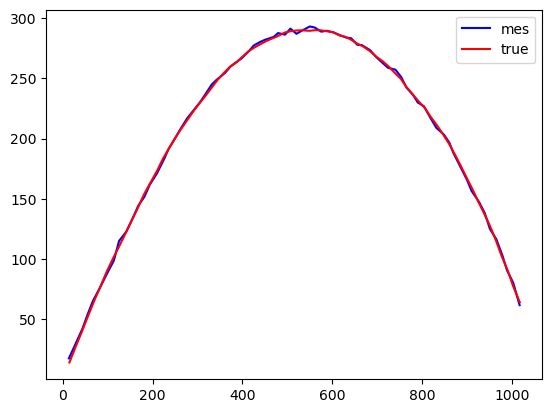

In [4]:
# Plot the true trajectory and the measurements

Mes = Measurements.T
xmes = Mes[0,:]
ymes = Mes[1,:]

St = States.T 
xtrue = St[0,:]
ytrue = St[2,:]

plt.plot(xmes, ymes, color='blue', label='mes')
plt.plot(xtrue, ytrue, color='red', label='true')
plt.legend()
plt.show()


2. Implement the Kalman predictor to track to trajectory based on the generated snapshots. To do so, fill the function below. 

In [5]:
#Define the Kalman predictor

def Kalman_predictor(Psi,Gammau,Phi,Q,R,P_0,x0barvec,Measurements,Nsteps):
    
    # Output : 
    # - Predicted_states, a Nsteps x 4 array containing the states at all time indexes
    
    Predicted_states = np.zeros((Nsteps,4),dtype=float)
    Predicted_states[0] = x0barvec.flatten()
    P = P_0
    G = Gammau.flatten()    
    for i in range(0, Nsteps - 1):
        inv = np.linalg.inv(Phi @ P @ Phi.T + R)
        K = Psi @ P @ Phi.T @ inv
        P = Psi @ P @ Psi.T + Q - K @ Phi @ P @ Psi.T
        Predicted_states[i+1] = (Psi - K @ Phi) @ Predicted_states[i] + (K @ Measurements[i]) + G
        
    return Predicted_states

3.   Plot in the same graph

    - the true (and unknown) trajectory;
    - the noisy measurements;
    - the estimated trajectory obtained using the Kalman filter;

In [6]:
# Apply the predictor on the measurements generated in the previous question

Predicted_states = Kalman_predictor(Psi,Gammau,Phi,Q,R,P_0,x0barvec,Measurements,Nsteps)

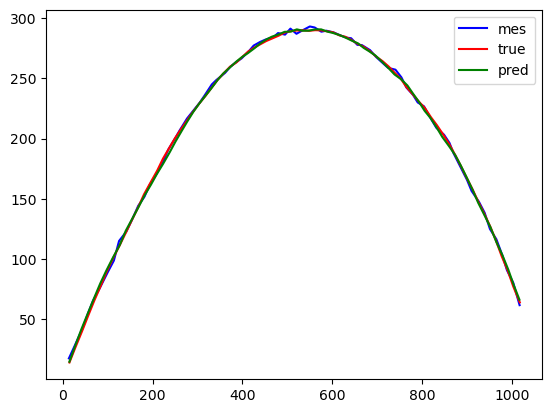

In [7]:
# Plot the true trajectory, the measurements and the predicted positions in the same graph

Pst = Predicted_states.T
xpred = Pst[0,:]
ypred = Pst[2,:]

plt.plot(xmes, ymes, color='blue', label='mes')
plt.plot(xtrue, ytrue, color='red', label='true')
plt.plot(xpred, ypred, color='green', label='pred')
plt.legend()
plt.show()

Comment your observations. Is your predictor able to estimate the trajectory? What is its limitation in terms of time horizon?

<font size=3 color=#12a0ff> **2.3 Exercise 2** </font> <br> 

At each iteration of the `Kalman_predictor` loop, you have access to an evaluation of the state vector $\hat{\boldsymbol{x}}_{k|k-1}$ and the posteriori accuracy in $\boldsymbol{P}_{k|k-1}$. Those two parameters provide, respectively, the mean and the covariance matrix of the distribution of $p(\boldsymbol{x}_k|\boldsymbol{y}_{0:k-1})$. To monitor its evolution, implement a new version `Kalman_predictor` function in order to save the covariance matrices $\boldsymbol{P}_{k|k-1}$ in its outputs (in a list for example). 

In [12]:
def Kalman_predictor_with_covariances(Psi,Gammau,Phi,Q,R,P_0,x0barvec,Measurements,Nsteps):
    
    # Output : 
    # - Predicted_states, a Nsteps x 4 array containing the states at all time indexes
    
    Predicted_states = np.zeros((Nsteps,4),dtype=float)
    covMatrices           = [P_0]
    Predicted_states[0] = x0barvec.flatten()
    P = P_0
    G = Gammau.flatten()    
    for i in range(0, Nsteps - 1):
        inv = np.linalg.inv(Phi @ P @ Phi.T + R)
        K = Psi @ P @ Phi.T @ inv
        P = Psi @ P @ Psi.T + Q - K @ Phi @ P @ Psi.T
        covMatrices.append(P)
        Predicted_states[i+1] = (Psi - K @ Phi) @ Predicted_states[i] + (K @ Measurements[i]) + G
        
    return Predicted_states, covMatrices

Now, plot again the true trajectory and the predicted positions in the same graph. But this time, for each prediction, plot a gaussian distribution of mean [$\hat{\textbf{x}}_x, \hat{\textbf{x}}_y$] and variance $\begin{bmatrix}
\sigma^2_x & 0 \\
0 & \sigma^2_y 
\end{bmatrix}$, centred on your prediction. You can use the function `plot_covariance_ellipse` to help you. Use a standard deviation of at least 3 for the std parameter of this function.

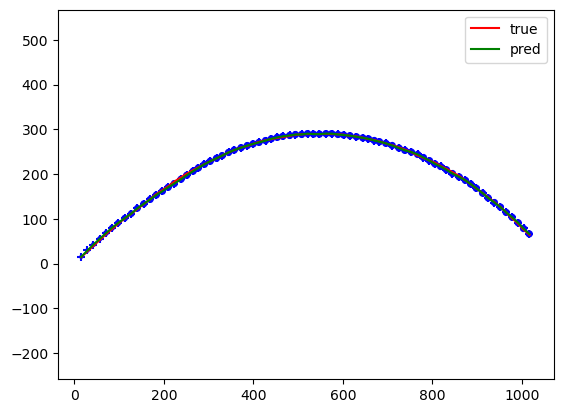

In [18]:
from make_graphs import plot_covariance_ellipse

#Apply the predictor
Predicted_states, covMatrices = Kalman_predictor_with_covariances(Psi,Gammau,Phi,Q,R,P_0,x0barvec,Measurements,Nsteps)

Pst = Predicted_states.T
xpred = Pst[0,:]
ypred = Pst[2,:]

plt.plot(xtrue, ytrue, color='red', label='true')
plt.plot(xpred, ypred, color='green', label='pred')
plt.legend()
for i in range(0, Nsteps):
    plot_covariance_ellipse([xpred[i], ypred[i]], cov = covMatrices[i], std=3.0, ec='blue')
plt.show()




What do you observe on the distributions? Which parameters can influence the symmetry of the distributions, along their x- and y-axes?

<font size=3 color=#12a0ff> **2.4 Exercise 3** </font> <br> 

The experiment performed in Exercise 1 can be repeated $N_{\exp}$ times (i.e. for $N_{\exp}$ different trajectories). For a given set of parameters, we define the mean square error of the filter as 

$$
\overline{\mathrm{MSE}} =
\frac{1}{N_{\mathrm{exp}}\, N_{\mathrm{steps}}}
\sum_{n=1}^{N_{\mathrm{exp}}}
\sum_{k=1}^{N_{\mathrm{steps}}}
\left[
\big(x_{n,\mathrm{pred}}(k) - x_{n,\mathrm{true}}(k)\big)^2
+
\big(y_{n,\mathrm{pred}}(k) - y_{n,\mathrm{true}}(k)\big)^2
\right]
$$

where $x_{n,\text{pred}}(k)$, $x_{n,\text{true}}(k)$, $y_{n,\text{pred}}(k)$ and $y_{n,\text{true}}(k)$ are the coordinates of the true and estimated positions at time step k in the nth generated trajectory. 

Consider the predictor implemented in the previous exercise. Study the impact on the MSE of the following parameters: 

- the time step $\Delta t$;
- the four variances $\sigma_1^2$,...,$\sigma_4^2$;

For each parameter, plot the MSE versus the values of the parameter. Comment your results.

In [25]:
Nexp = 100

MSE = 0.0

for n in range(0, Nexp):
    x0 = (x0bar + sigma_4*np.random.randn(1))[0]
    y0 = (y0bar + sigma_4*np.random.randn(1))[0]
    vx0 = vx0bar 
    vy0 = vy0bar 

    x0vec = np.array([[x0, vx0, y0, vy0]]).T

    States, Measurements = traj_and_mes(Psi,Gammau,Phi,Q,R,x0vec,Nsteps)
    
    Predicted_states = Kalman_predictor(Psi,Gammau,Phi,Q,R,P_0,x0barvec,Measurements,Nsteps)

    St = States.T 
    xtrue = St[0,:]
    ytrue = St[2,:]
    
    Pst = Predicted_states.T
    xpred = Pst[0,:] 
    ypred = Pst[2,:]
    
    error = np.square(xpred-xtrue) + np.square(ypred-ytrue)
    MSE += np.sum(error)
    
print(MSE / (float(Nexp)*float(Nsteps)))

/tmp/ipykernel_15813/4105033447.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Measurements[0,0] = x0vec[0] + np.sqrt(R[0,0])*np.random.randn(1)
/tmp/ipykernel_15813/4105033447.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Measurements[0,1] = x0vec[2] + np.sqrt(R[1,1])*np.random.randn(1)


0.7086433592745347


<font size=3 color=#12a0ff> **2.5 Exercise 4 (BONUS)** </font> <br> 

Modeling the nonlinear effects of the motion as a Gaussian perturbation is of course very inaccurate. In practice, these forces are anything but Gaussian. In [1], an analytical expression
is proposed to model the drag force (wind resistance) as function of the speed of the missile
    
$$F_{drag} = -B_2v^2$$

where $B_2$ is a coefficient derived experimentally and $v = \sqrt{v_x^2+v_y^2}$.

This force can be decomposed into its x- and y- components 

$$\begin{aligned}
F_{drag,x} &= -B_2v v_x\\
F_{drag,y} &= -B_2v v_y
\end{aligned}$$

Since we are considering a unit mass body, the acceleration is therefore given by 

$$\begin{aligned} 
a_x &= - B_2 v v_x = - B_2 \sqrt{v_x^2+v_y^2} \; v_x \\
a_y &= - B_2 v v_y = - B_2 \sqrt{v_x^2+v_y^2} \; v_y
\end{aligned}$$

Still for a unit mass body, a possible approximation for $B_2$ is given by 

$$B_2 = 0.0039 + \frac{0.0058}{1+\exp{[(v-35)/5]}}$$

The above expressions depend on the speed in a nonlinear manner. The traditional Kalman filter that has been used so far cannot properly takes nonlinear forces into account. The required state model must be of the form $\boldsymbol{x}_{k+1} = \boldsymbol{\Psi}\boldsymbol{x}_k + \boldsymbol{\Gamma}\boldsymbol{u}_k + \boldsymbol{\xi}_k$ where the future state only linearly depends on the previous one, and where the terms $\boldsymbol{\Gamma}\boldsymbol{u}_k + \boldsymbol{\xi}_k$ are independent of $\boldsymbol{x}_k$. The expression of the drag force cannot be captured by such state model. 

For this reason, we can fortunately resort to the *extended Kalman filter* (EKF) or the *unscented Kalman filter* (UKF). These filters are improved versions of the traditional KF enabling to deal with nonlinear state models. 

In this exercise, you are asked to implement these two filters and to apply them on the previous scenario (including the drag force). Compare their performances.

Nb: since the EKF and UKF have not been covered during the lecture, this exercise is left as 'challenge'. You will have to search in the literature/on the web to find out how to implement these filters. Here are a few potential webpages: 

- https://www.cs.cmu.edu/~motionplanning/papers/sbp_papers/kalman/ekf_lecture_notes.pdf
- https://stanford.edu/class/ee363/lectures/ekf.pdf
- https://www.seas.harvard.edu/courses/cs281/papers/unscented.pdf
- https://www.cse.sc.edu/~terejanu/files/tutorialUKF.pdf

<font size=3 color=#12a0ff> **Reference** </font> <br> 

[1] N. Giordano, H. Nakanishi, *Computational Physics*, 1997

In [11]:
# Your code here 